# Azerbaijani Apartment Price Prediction

In this project, I will build a machine learning model to predict house prices.
The dataset is based on apartment listings from Azerbaijan, mainly Baku.

The main goal is to practice a full regression workflow:
- loading a real dataset
- exploring the data
- preprocessing features
- training models
- evaluating model performance

## Import Libraries

Import libraries that will be used for data analysis, visualization, preprocessing, and machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load the Dataset

I saved the Azerbaijan apartment price dataset inside the `data` folder. 
It includes information such as location, number of rooms, apartment area, floor, building type, repair status, bill of sale, mortgage availability, and price.
The file is loaded with pandas from a local CSV file.

In [2]:
df = pd.read_csv("data/BakuApartmentData.csv", index_col=0)
df.head()

,price,location,rooms,square,floor,new_building,has_repair,has_bill_of_sale,has_mortgage
0,177000,Həzi Aslanov m.,4,117.0,12/16,1,1,1,1
1,190000,Şah İsmayıl Xətai m.,2,80.0,5/16,1,1,1,1
2,430000,Elmlər Akademiyası m.,4,170.0,3/17,1,1,1,1
3,465000,Elmlər Akademiyası m.,4,186.0,9/15,1,1,1,1
4,265500,28 May m.,3,96.0,8/16,1,1,1,1


The first unnamed column in the CSV is only an old index, so I used `index_col=0` while reading the file.

The target column is `price`. This is the value that the model will try to predict later.

## Data Cleaning

Before doing EDA and model training, I need to clean the dataset.

This dataset was scraped from apartment listings in Azerbaijan, so repeated listings are possible. I noticed that some rows have the same `price`, `location`, `rooms`, `square`, and `floor`, but different binary columns.

My idea is to treat these rows as the same apartment listing and keep one row for each repeated apartment.

In [3]:
original_rows = df.shape[0]
original_columns = df.shape[1]

print("Original rows:", original_rows)
print("Original columns:", original_columns)

Original rows: 458075
Original columns: 9


### Missing Values

First, I check missing values. Missing data can create problems during analysis and model training.

In [4]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0].sort_values(ascending=False)

Series([], dtype: int64)

In [5]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


### Duplicate Rows

Now I check full duplicates and duplicates based on the main apartment information.

In [6]:
main_duplicate_columns = ["price", "location", "rooms", "square", "floor"]

full_duplicates = df.duplicated().sum()
main_duplicates = df.duplicated(subset=main_duplicate_columns).sum()

print("Full duplicate rows:", full_duplicates)
print("Duplicate rows by main apartment columns:", main_duplicates)

Full duplicate rows: 74506
Duplicate rows by main apartment columns: 425143


Some listings repeat with the same main apartment information, while columns like repair, mortgage, or bill of sale may be different.

For these repeated listings, I will keep one row and use the maximum value for binary columns. For example, if one repeated row says mortgage is available, I keep it as available.

In [7]:
binary_columns = [
    "new_building",
    "has_repair",
    "has_bill_of_sale",
    "has_mortgage"
]

df_clean = (
    df.groupby(main_duplicate_columns, as_index=False)[binary_columns]
    .max()
)

df_clean.head()

,price,location,rooms,square,floor,new_building,has_repair,has_bill_of_sale,has_mortgage
0,9600,Həzi Aslanov m.,1,26.0,1/9,0,0,1,0
1,17000,Sahil m.,1,12.0,1/2,0,1,1,1
2,23000,Masazır q.,1,24.0,1/5,1,1,1,1
3,25000,Bakıxanov q.,1,20.0,1/5,0,0,1,0
4,25000,Yeni Yasamal q.,2,72.0,7/16,1,1,1,1


### Basic Value Checks

I also check if there are impossible values, such as zero or negative price, rooms, or apartment area.

In [8]:
invalid_price = (df_clean["price"] <= 0).sum()
invalid_rooms = (df_clean["rooms"] <= 0).sum()
invalid_square = (df_clean["square"] <= 0).sum()

print("Invalid price rows:", invalid_price)
print("Invalid rooms rows:", invalid_rooms)
print("Invalid square rows:", invalid_square)

Invalid price rows: 0
Invalid rooms rows: 0
Invalid square rows: 0


In [9]:
df_clean = df_clean[
    (df_clean["price"] > 0) &
    (df_clean["rooms"] > 0) &
    (df_clean["square"] > 0)
].copy()

### Cleaning Summary

Finally, I compare the dataset size before and after cleaning.

In [10]:
cleaned_rows = df_clean.shape[0]
removed_rows = original_rows - cleaned_rows

print("Original rows:", original_rows)
print("Cleaned rows:", cleaned_rows)
print("Removed rows:", removed_rows)
print("Removed percent:", round(removed_rows / original_rows * 100, 2), "%")

Original rows: 458075
Cleaned rows: 32932
Removed rows: 425143
Removed percent: 92.81 %


In [11]:
print("Missing values after cleaning:", df_clean.isnull().sum().sum())

Missing values after cleaning: 0


After cleaning, the dataset size decreased a lot. This happened because the raw scraped data contained many repeated apartment listings.

I grouped apartments by the main description columns: `price`, `location`, `rooms`, `square`, and `floor`. For repeated listings, I kept one row and combined the binary columns using the maximum value.

Even though 92.81% of rows were removed, this does not mean that most data was useless. It mainly means the original dataset had many duplicate copies of the same listings.

In [12]:
df = df_clean.copy()
df.head()

,price,location,rooms,square,floor,new_building,has_repair,has_bill_of_sale,has_mortgage
0,9600,Həzi Aslanov m.,1,26.0,1/9,0,0,1,0
1,17000,Sahil m.,1,12.0,1/2,0,1,1,1
2,23000,Masazır q.,1,24.0,1/5,1,1,1,1
3,25000,Bakıxanov q.,1,20.0,1/5,0,0,1,0
4,25000,Yeni Yasamal q.,2,72.0,7/16,1,1,1,1


## Basic Dataset Information


In [13]:
df.columns

Index(['price', 'location', 'rooms', 'square', 'floor', 'new_building',
       'has_repair', 'has_bill_of_sale', 'has_mortgage'],
      dtype='str')

I will check the data types. This is important because numeric and categorical columns will need different preprocessing steps later.

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32932 entries, 0 to 32931
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             32932 non-null  int64  
 1   location          32932 non-null  str    
 2   rooms             32932 non-null  int64  
 3   square            32932 non-null  float64
 4   floor             32932 non-null  str    
 5   new_building      32932 non-null  int64  
 6   has_repair        32932 non-null  int64  
 7   has_bill_of_sale  32932 non-null  int64  
 8   has_mortgage      32932 non-null  int64  
dtypes: float64(1), int64(6), str(2)
memory usage: 2.3 MB


## Summary Statistics

Here I look at simple summary statistics for numeric columns, such as mean, minimum, maximum, and standard deviation.

In [15]:
df.describe()

,price,rooms,square,new_building,has_repair,has_bill_of_sale,has_mortgage
count,3.293200e+04,32932.000000,32932.000000,32932.000000,32932.000000,32932.0,32932.000000
mean,2.331518e+05,2.819507,106.820060,0.755284,0.989251,1.0,0.991467
std,1.901053e+05,0.941958,61.271732,0.429925,0.103122,0.0,0.091979
min,9.600000e+03,1.000000,12.000000,0.000000,0.000000,1.0,0.000000
25%,1.348000e+05,2.000000,65.000000,1.000000,1.000000,1.0,1.000000
50%,1.866000e+05,3.000000,94.000000,1.000000,1.000000,1.0,1.000000
75%,2.800000e+05,3.000000,132.000000,1.000000,1.000000,1.0,1.000000
max,8.075000e+06,20.000000,1600.000000,1.000000,1.000000,1.0,1.000000


## Missing Values

Finally, I check missing values. This will help me decide what preprocessing steps are needed in the next parts of the project.

If a column has missing values, I will later decide whether to fill them, remove rows, or handle them with a preprocessing pipeline.

In [16]:
missing_values = df.isnull().sum()

missing_values

price               0
location            0
rooms               0
square              0
floor               0
new_building        0
has_repair          0
has_bill_of_sale    0
has_mortgage        0
dtype: int64

In [17]:
missing_values.sort_values(ascending=False)

price               0
location            0
rooms               0
square              0
floor               0
new_building        0
has_repair          0
has_bill_of_sale    0
has_mortgage        0
dtype: int64

This check shows which columns have missing data and how many missing values each column contains.
In the preprocessing step, I will handle missing values before training the models.

## Exploratory Data Analysis

The main goal is to understand apartment prices in Baku and see how price changes by location, number of rooms, and apartment size.

### Price Distribution

First, I look at the distribution of apartment prices. This helps me understand the general price range and whether there are very expensive apartments in the dataset.

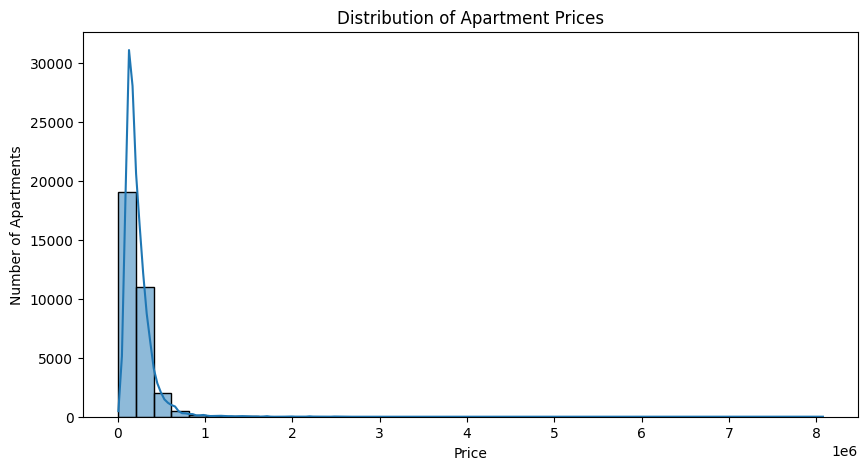

In [18]:
plt.figure(figsize=(10, 5))
sns.histplot(df["price"], bins=40, kde=True)

plt.title("Distribution of Apartment Prices")
plt.xlabel("Price")
plt.ylabel("Number of Apartments")
plt.show()

Most apartment prices are concentrated in the lower price range. The distribution is strongly right-skewed, which means there are a few very expensive apartments compared to the majority of listings.

Because of these high-price listings, I should check possible outliers later before training the models.

In [19]:
df.sort_values("price", ascending=False).head(10)

,price,location,rooms,square,floor,new_building,has_repair,has_bill_of_sale,has_mortgage
32931,8075000,İçəri Şəhər m.,4,315.0,6/19,1,1,1,1
32930,6800000,Nizami m.,15,1600.0,24/24,1,1,1,1
32929,5100000,Sahil m.,5,300.0,14/22,1,1,1,1
32928,5000000,Səbail r.,8,1050.0,11/33,1,1,1,1
32927,4000000,Şah İsmayıl Xətai m.,13,535.0,1/18,1,1,1,1
32926,3600000,Gənclik m.,8,784.0,16/17,1,1,1,1
32925,3555000,Gənclik m.,4,285.0,10/15,1,1,1,1
32924,3400000,Nəriman Nərimanov m.,6,340.0,11/15,1,1,1,1
32923,3200000,Nəriman Nərimanov m.,5,295.0,11/15,1,1,1,1
32922,3200000,Nəriman Nərimanov m.,4,165.0,10/16,1,1,1,1


This table helps see possible luxury apartments or outliers. Very expensive apartments are not always errors, but they can strongly affect model training later.

### Cheapest Apartments

I also check the cheapest apartments because very low prices may be unusual or may represent small apartments, old buildings, or listings with missing details.

In [20]:
df.sort_values("price").head(10)  # ascending default is True

,price,location,rooms,square,floor,new_building,has_repair,has_bill_of_sale,has_mortgage
0,9600,Həzi Aslanov m.,1,26.0,1/9,0,0,1,0
1,17000,Sahil m.,1,12.0,1/2,0,1,1,1
2,23000,Masazır q.,1,24.0,1/5,1,1,1,1
3,25000,Bakıxanov q.,1,20.0,1/5,0,0,1,0
4,25000,Yeni Yasamal q.,2,72.0,7/16,1,1,1,1
5,26000,Sabunçu q.,1,28.0,2/2,0,0,1,0
6,27000,Binəqədi r.,1,57.0,12/12,1,1,1,1
7,28000,Ramana q.,3,80.0,1/1,0,1,1,1
8,28000,Səbail r.,2,50.0,2/2,0,0,1,0
9,28500,Maştağa q.,2,50.0,2/2,0,1,1,1


Checking the cheapest listings is useful because extremely low values can sometimes be data entry mistakes. I will not remove anything yet, but I will keep these values in mind for preprocessing.

### Price by Number of Rooms

Now I compare apartment prices by number of rooms. In general, apartments with more rooms should have higher prices.

In [21]:
room_price = df.groupby("rooms")["price"].mean().sort_index()
room_price

rooms
1     1.029866e+05
2     1.477406e+05
3     2.324701e+05
4     3.743078e+05
5     4.715108e+05
6     7.931590e+05
7     9.831604e+05
8     1.426850e+06
9     1.408900e+06
10    2.164000e+06
11    1.680000e+06
12    2.600000e+05
13    4.000000e+06
14    1.200000e+06
15    3.203333e+06
20    2.300000e+06
Name: price, dtype: float64

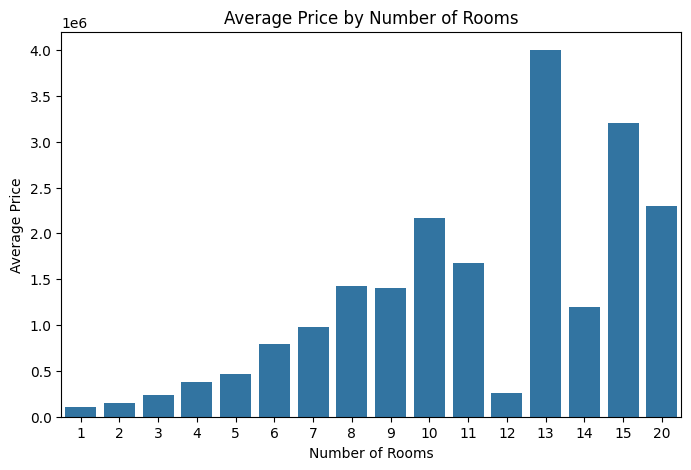

In [22]:
plt.figure(figsize=(8, 5))
sns.barplot(x=room_price.index, y=room_price.values)

plt.title("Average Price by Number of Rooms")
plt.xlabel("Number of Rooms")
plt.ylabel("Average Price")
plt.show()

This chart shows the average apartment price for each room count. It gives a simple first look at how apartment size category relates to price.

### Price per Square Meter

Apartment price alone is not always enough. A large apartment can be expensive mainly because it has more space. That is why I will create a simple `price_per_sqm` column.

In [23]:
df["price_per_sqm"] = df["price"] / df["square"]

df[["price", "square", "price_per_sqm"]].head()

,price,square,price_per_sqm
0,9600,26.0,369.230769
1,17000,12.0,1416.666667
2,23000,24.0,958.333333
3,25000,20.0,1250.000000
4,25000,72.0,347.222222


The 'price_per_sqm' column helps compare apartments with different sizes more fairly.

In [24]:
df["price_per_sqm"].describe()

count    32932.000000
mean      2158.202434
std        695.193343
min        269.541779
25%       1762.567446
50%       2076.923077
75%       2464.285714
max      25634.920635
Name: price_per_sqm, dtype: float64

### Most Expensive Locations by Average Price

Now I check which locations have the highest average apartment prices. To make the result more reliable, I only include locations with at least 20 listings.

In [25]:
location_stats = (
    df.groupby("location")
    .agg(
        average_price=("price", "mean"),
        average_price_per_sqm=("price_per_sqm", "mean"),
        apartment_count=("price", "count")
    )
    .sort_values("average_price", ascending=False)
)

popular_locations = location_stats[location_stats["apartment_count"] >= 20]

popular_locations.head(10)

,average_price,average_price_per_sqm,apartment_count
location,,,
Sahil m.,463863.471503,3390.875385,386
Ağ şəhər q.,428336.917772,2872.756889,377
İçəri Şəhər m.,407697.184549,3211.581765,466
Nardaran q.,353490.820896,3534.902200,67
Səbail r.,340252.694690,2545.481617,226
Nizami m.,335478.045230,2498.285902,1216
28 May m.,334223.782069,2492.376973,1450
Elmlər Akademiyası m.,332443.408062,2532.681976,1414
Şah İsmayıl Xətai m.,325613.761986,2402.242575,1752


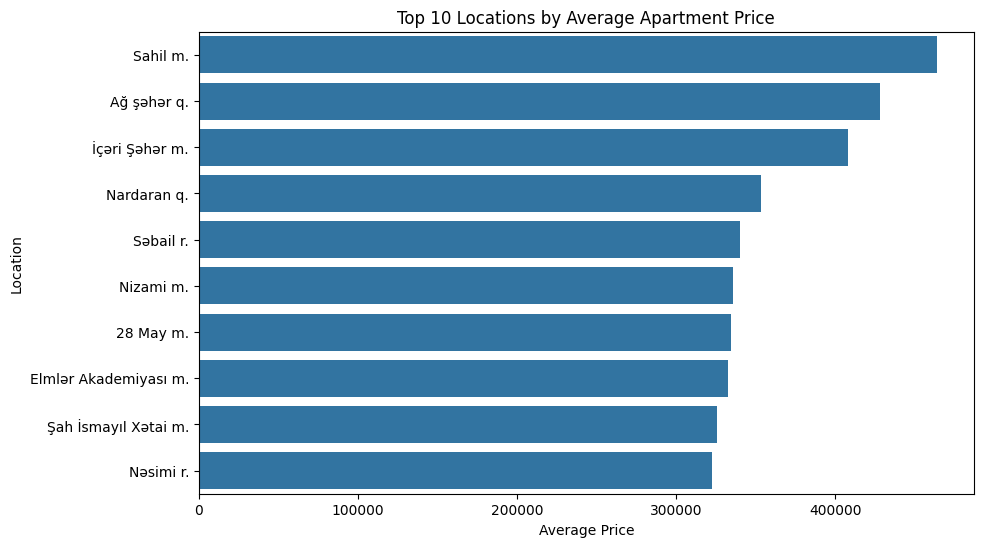

In [26]:
top_locations = popular_locations.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_locations,
    x="average_price",
    y=top_locations.index
)

plt.title("Top 10 Locations by Average Apartment Price")
plt.xlabel("Average Price")
plt.ylabel("Location")
plt.show()

This chart gives a first view of where apartments are more expensive in Baku. I used locations with at least 20 listings because locations with only a few listings can give misleading averages.

### Apartment Area vs Price

Finally, I check the relationship between apartment area and price. Usually, larger apartments should cost more.

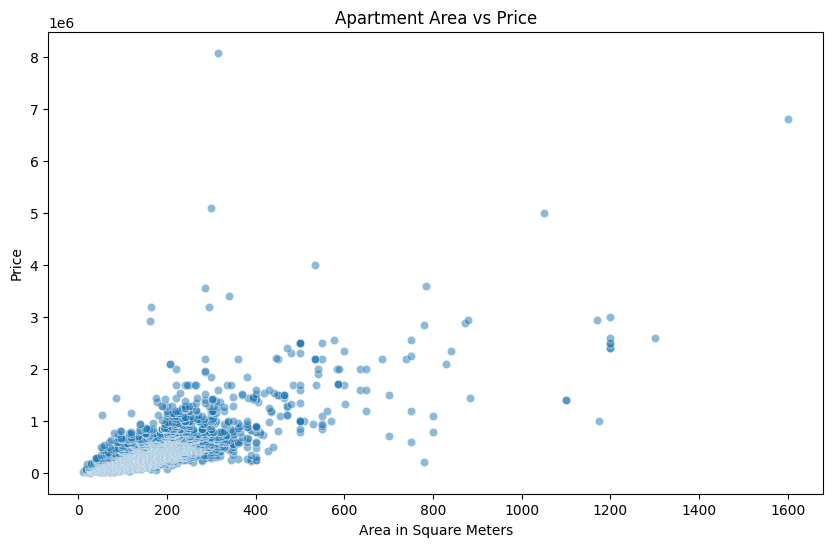

In [27]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="square", y="price", alpha=0.5)

plt.title("Apartment Area vs Price")
plt.xlabel("Area in Square Meters")
plt.ylabel("Price")
plt.show()

The scatter plot shows the relationship between apartment area and price. If the points generally move upward, it means larger apartments usually have higher prices.

## Feature Engineering

The `floor` column contains two values in one text column, for example `6/19`. I will split it into apartment floor and total building floors.

In [28]:
df[["apartment_floor", "building_floors"]] = df["floor"].str.split("/", expand=True)

df["apartment_floor"] = df["apartment_floor"].astype(int)
df["building_floors"] = df["building_floors"].astype(int)

df["is_last_floor"] = (df["apartment_floor"] == df["building_floors"]).astype(int)

df.head()

,price,location,rooms,square,floor,new_building,has_repair,has_bill_of_sale,has_mortgage,price_per_sqm,apartment_floor,building_floors,is_last_floor
0,9600,Həzi Aslanov m.,1,26.0,1/9,0,0,1,0,369.230769,1,9,0
1,17000,Sahil m.,1,12.0,1/2,0,1,1,1,1416.666667,1,2,0
2,23000,Masazır q.,1,24.0,1/5,1,1,1,1,958.333333,1,5,0
3,25000,Bakıxanov q.,1,20.0,1/5,0,0,1,0,1250.000000,1,5,0
4,25000,Yeni Yasamal q.,2,72.0,7/16,1,1,1,1,347.222222,7,16,0


In [29]:
df = df.drop(columns=["floor"])

## Preprocessing

Before training models, I split the data into features and target. I will not use `price_per_sqm` as a model feature because it is calculated from the target column `price`.

## Import Libraries

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [31]:
X = df.drop(columns=["price", "price_per_sqm"], errors="ignore")
y = df["price"]

X.head()

,location,rooms,square,new_building,has_repair,has_bill_of_sale,has_mortgage,apartment_floor,building_floors,is_last_floor
0,Həzi Aslanov m.,1,26.0,0,0,1,0,1,9,0
1,Sahil m.,1,12.0,0,1,1,1,1,2,0
2,Masazır q.,1,24.0,1,1,1,1,1,5,0
3,Bakıxanov q.,1,20.0,0,0,1,0,1,5,0
4,Yeni Yasamal q.,2,72.0,1,1,1,1,7,16,0


In [32]:
numeric_features = [
    "rooms",
    "square",
    "new_building",
    "has_repair",
    "has_bill_of_sale",
    "has_mortgage",
    "apartment_floor",
    "building_floors",
    "is_last_floor"
]

categorical_features = ["location"]

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [35]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])